# Notebook 1: Exploratory Data Analysis (EDA)
---
**Project:** Audio Recommendation Algorithm 

**Dataset:** Songs from 1950–2019 (28,362 songs, 24 columns)

**Goal:** Explore the dataset to understand distributions, relationships between features, and genre patterns before building a clustering model. This notebook is organized into three sections:
1. **Univariate Analysis** — examine one column at a time
2. **Bivariate Analysis** — compare two columns at a time
3. **Multivariate Analysis** — explore patterns across many columns together

---
## Setup: Imports and Data Loading

Import all required libraries and load the training dataset. We then run a preliminary investigation using `.info()` to check column types and null counts, and `.describe()` for basic statistics. This is always the first step before any analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy import stats

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Load the training dataset
# .info() shows column types and non-null counts
# .describe() shows min, max, mean, and std for all numeric columns
df = pd.read_csv('/Users/saadult/Music Rec Algo/Music-Recommendation-Algorithm/data/train.csv')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000
mean,42948.166878,1990.239652,73.030534,0.021110,0.118371,0.120984,0.057356,0.017418,0.017045,0.048676,0.076651,0.097185,0.060067,0.047417,0.049008,0.024155,0.129402,0.030995,0.425148
std,24747.811462,18.486997,41.831605,0.052366,0.178658,0.172216,0.111892,0.040658,0.041968,0.106071,0.109497,0.181314,0.123346,0.091559,0.089553,0.051032,0.181149,0.071656,0.264100
min,0.000000,1950.000000,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,0.000284,0.000284,0.000284,0.000284,0.000289,0.014286
25%,20393.500000,1975.000000,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,0.001144,0.001053,0.000975,0.000993,0.000993,0.000957,0.001144,0.000993,0.185714
50%,45407.000000,1991.000000,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,0.002632,0.001815,0.001815,0.001645,0.001815,0.001645,0.005263,0.001754,0.414286
75%,64089.500000,2007.000000,93.000000,0.004049,0.192538,0.197854,0.065778,0.009989,0.004785,0.042304,0.132111,0.088799,0.055109,0.054373,0.064302,0.025515,0.235115,0.032617,0.642857
max,82451.000000,2019.000000,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,0.638021,0.667782,0.618073,0.981424,0.958810,1.000000


**What this shows:** `.info()` confirms 28,362 songs across 24 columns with no missing values — all columns show 28,362 non-null counts. This means we will not need to drop rows due to nulls, though we will still need to drop irrelevant columns (like `lyrics` and `Unnamed: 0`) in the cleaning step.

**Finding:** Dataset is complete with no missing values. The score columns are all `float64`, confirming they are ready for numerical analysis.

In [ ]:
isnull = df.isnull().sum()
print(isnull)

Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64


**Finding:** All columns return 0 null values

---
## Define Score Columns

We separate the 15 lyrical theme score columns (0–1 float values) from the identity columns (`artist_name`, `track_name`, etc.). All EDA and modeling will focus on these score columns since they are the numeric features the clustering algorithm will learn from.

In [ ]:
# These are the only columns fed into the clustering model
score_cols = [
    'dating', 'violence', 'world/life', 'night/time',
    'shake the audience', 'family/gospel', 'romantic',
    'communication', 'obscene', 'music', 'movement/places',
    'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings'
]

print(f'Number of score columns: {len(score_cols)}')
print(f'Score columns: {score_cols}')

Number of score columns: 15
Score columns: ['dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings']


---
## Step 1: Univariate Analysis

Univariate analysis examines one column at a time. The goal is to understand the shape and spread of each feature independently. We use histograms to see distributions and variance scores to rank each feature's clustering power. Features with very low variance (most songs pile up near the same value) will have weak clustering power and are candidates for removal.

### 1a. Genre Distribution

This bar chart shows how many songs belong to each genre. We check for class imbalance so if one genre dominates the dataset, the clustering algorithm may be biased toward that genre's lyrical patterns even though genre is never directly fed into the model.

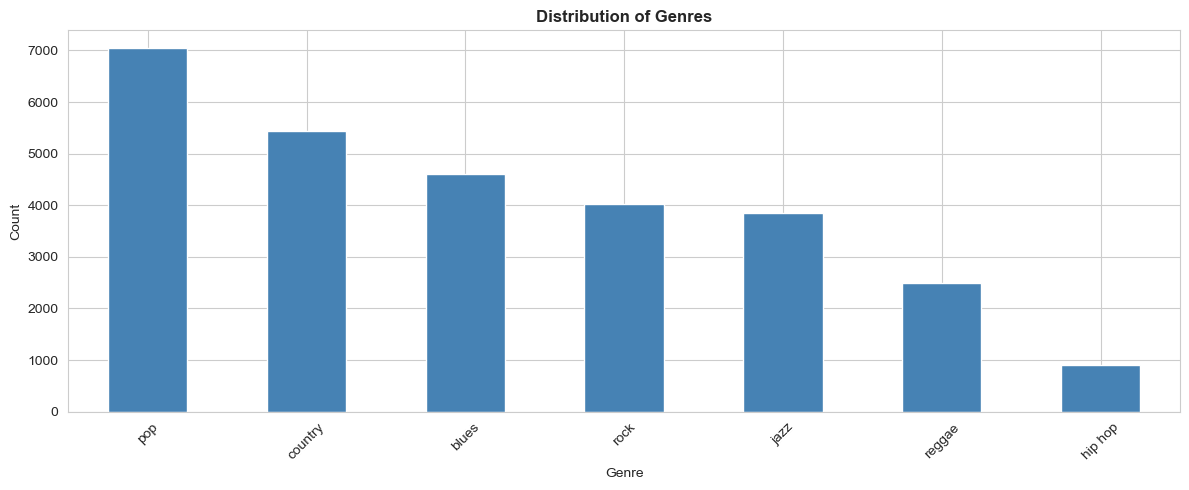

In [5]:

df['genre'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribution of Genres', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** Pop dominates the dataset with the highest song count, followed by rock and country. Hip hop and reggae are underrepresented. This imbalance means our clusters may skew toward pop song patterns, but since genre is not a model input, this is noted rather than corrected.

### 1b. Topic Distribution

This bar chart shows the distribution of the **topic** column, We use this later to validate our clusters: if songs labeled **violence** cluster together, the model is working correctly.

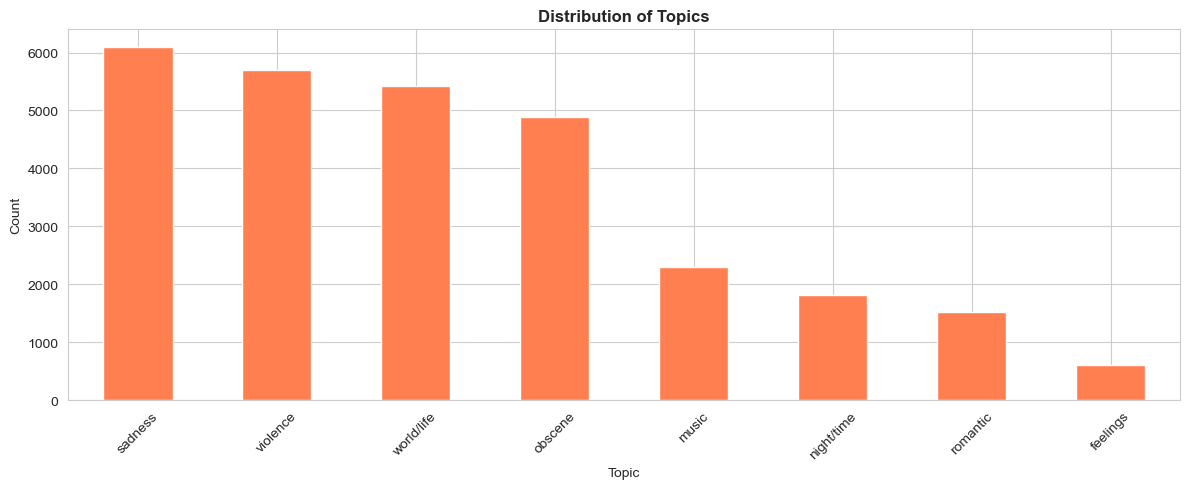

In [ ]:

df['topic'].value_counts().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Distribution of Topics', fontweight='bold')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** `world/life` and `romantic` are the most common lyrical topics. Topics like `music` and `night/time` appear far less frequently. This distribution will serve as a reference point when we interpret our clusters later. We expect the dominant topics to drive cluster separation.

### 1c. Individual Score Distributions

We examine three individual score columns **sadness**, **feelings**, and **dating** before running all histograms at once. We will be able to observe what the different distribution shapes look like and then figure out why they matter for clustering.

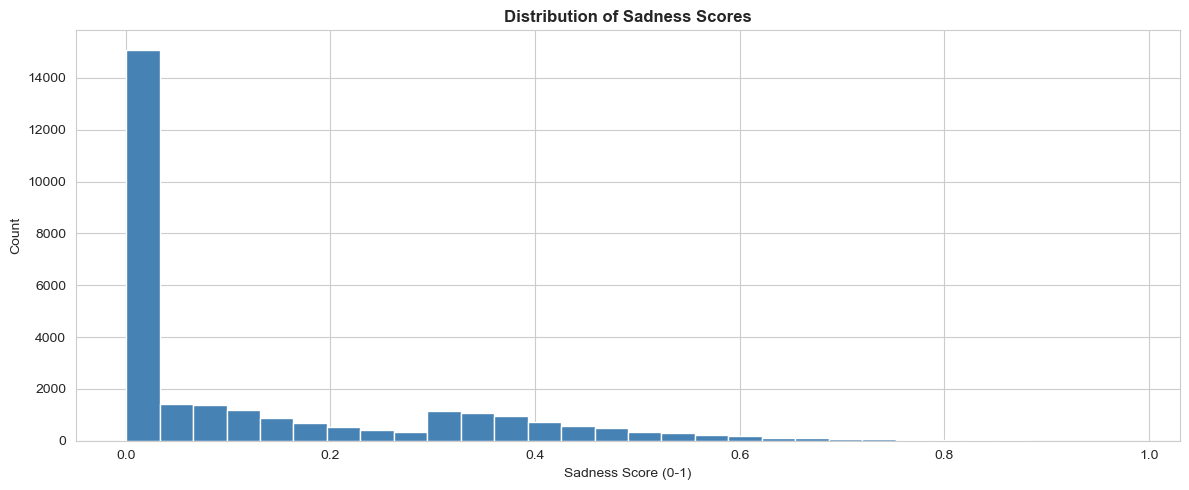

In [ ]:

df['sadness'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Sadness Scores', fontweight='bold')
plt.xlabel('Sadness Score (0-1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**What this shows:** The `sadness` score distribution is heavily right-skewed. Roughly 15,000 songs pile up near 0 with a secondary bump around 0.3–0.4. Most songs are not lyrically sad. This feature has moderate clustering power. This means it can separate notably sad songs from the majority but it won't help us distinguish most songs from each other.

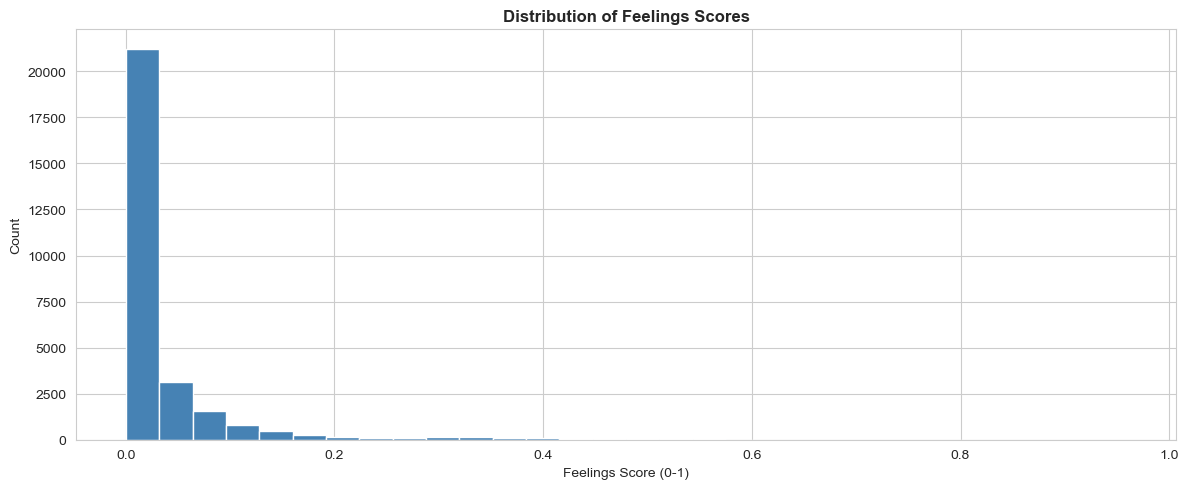

In [ ]:
df['feelings'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Feelings Scores', fontweight='bold')
plt.xlabel('Feelings Score (0-1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Finding:** `feelings` shows a similar right-skewed pattern to `sadness`. The distribution has a longer tail than sadness, suggesting slightly more spread but still most likely a weak cluster that would happen.

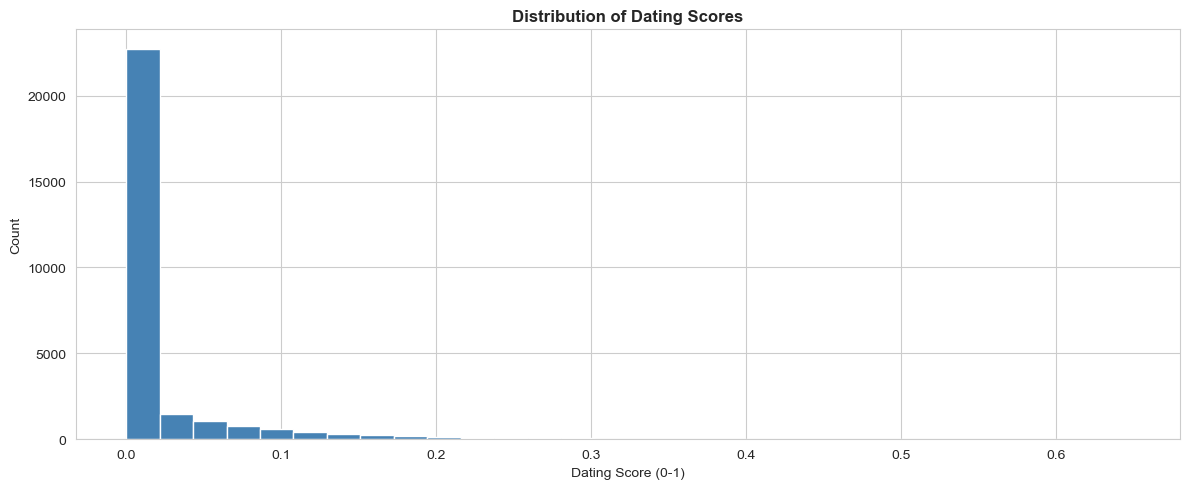

In [ ]:
df['dating'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Dating Scores', fontweight='bold')
plt.xlabel('Dating Score (0-1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Finding:** `dating` is extremely concentrated near 0 (even more so than `sadness`). The vast majority of songs have an almost zero dating score. This is a strong signal that `dating` has very low clustering power and can be dropped.

### 1d. All Score Columns —> Histogram Grid

Rather than examining 15 histograms individually, we plot all score columns in a single grid. This allows a quick visual scan to identify which columns are heavily skewed (weak features) versus more spread out (stronger features for clustering).

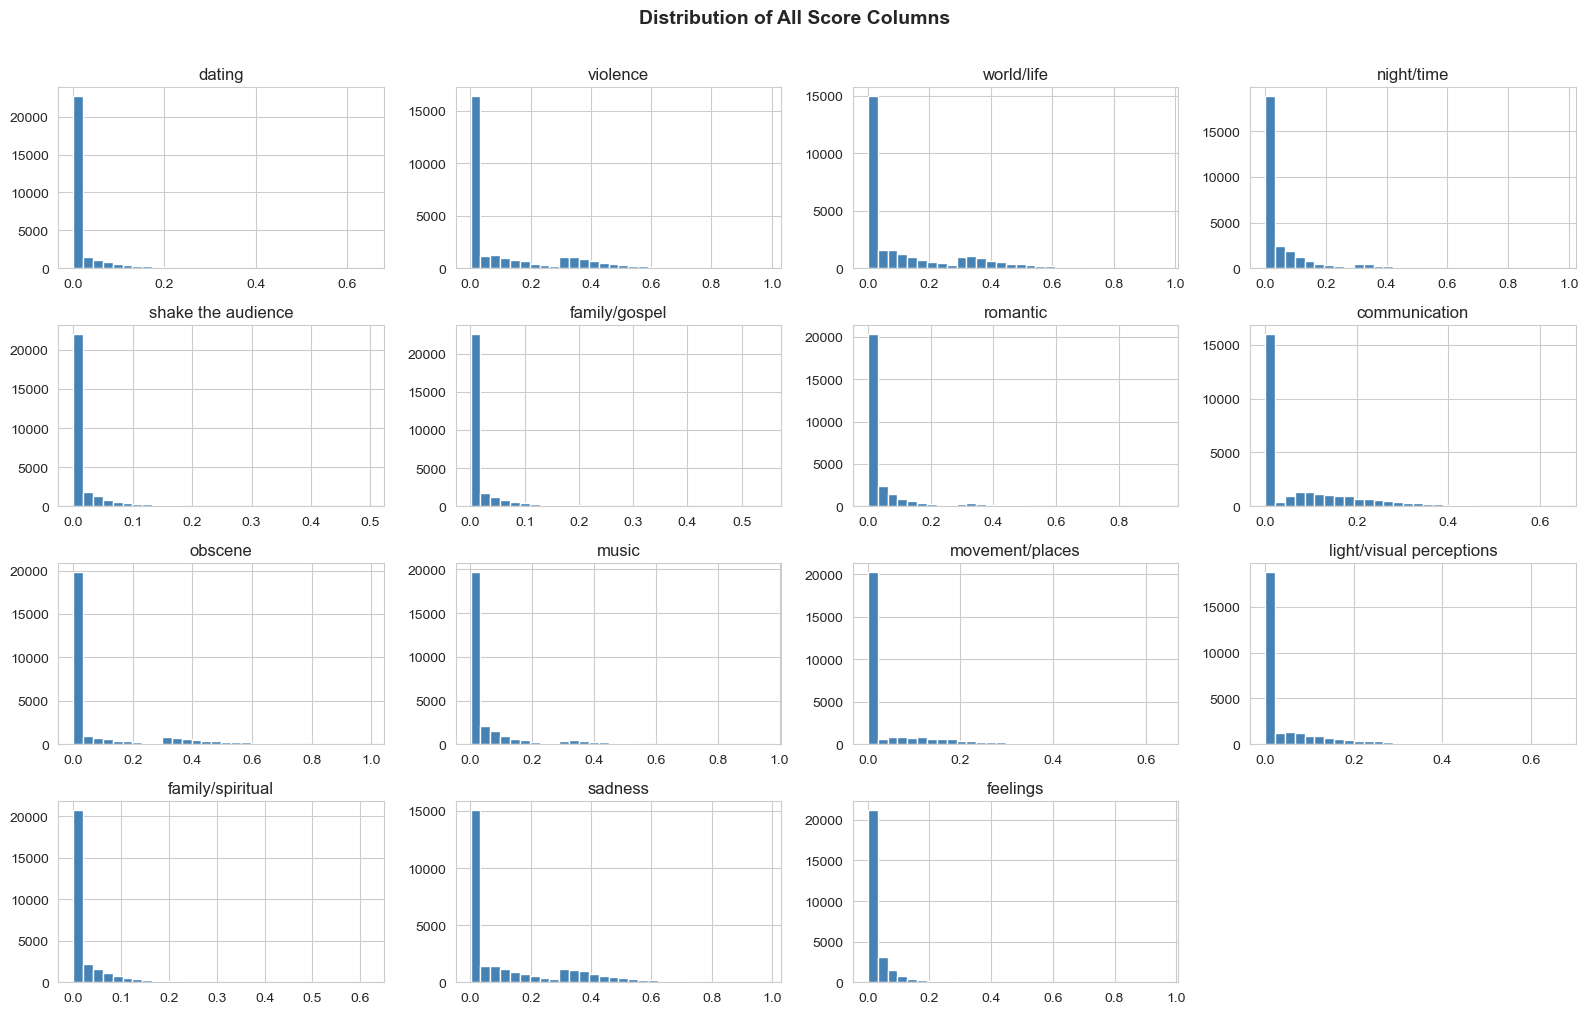

In [ ]:
df[score_cols].hist(bins=30, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of All Score Columns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Finding:** The majority of score columns are right-skewed, with mass concentrated near zero. The most visibly spread out columns are `violence`, `obscene`, `sadness`, and `world/life`. These show the widest distributions and can most likely be used for clustering. Columns like `shake the audience`, `family/gospel`, `family/spiritual`, and `dating` are extremely compressed near zero. (Most likely not a lot of variance which we will check next)

### 1e. Variance Ranking

Variance mathematically measures how spread out each column is. Instead of eyeballing histograms, we sort all score columns by variance: lowest to highest. Low variance means most songs score nearly the same value on that feature, making it nearly useless for separating songs into distinct groups. The threshold that was chose to flag the weakest candidates for removal is 0.003.

In [22]:
variances = df[score_cols].var().sort_values()
print('Variance per score column:')
print(variances.round(6))
print()
print('Candidates to drop (bcs variance is < 0.003):')
print(variances[variances < 0.003].index.tolist())

Variance per score column:
shake the audience          0.001653
family/gospel               0.001761
family/spiritual            0.002604
dating                      0.002742
feelings                    0.005135
light/visual perceptions    0.008020
movement/places             0.008383
romantic                    0.011251
communication               0.011990
night/time                  0.012520
music                       0.015214
world/life                  0.029658
violence                    0.031919
sadness                     0.032815
obscene                     0.032875
dtype: float64

Candidates to drop (bcs variance is < 0.003):
['shake the audience', 'family/gospel', 'family/spiritual', 'dating']


### 1f. Variance Bar Chart

Visual representation of the variance ranking above. The red dashed line marks the 0.003 threshold — columns to the left of this line are considered weak features with insufficient spread to contribute meaningful separation in the clustering model.

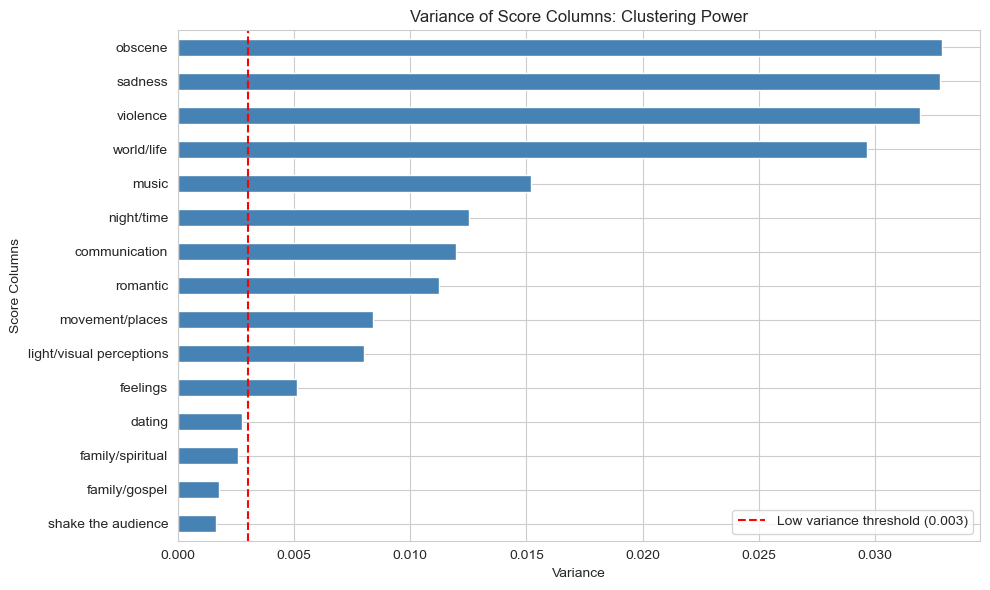

In [23]:
variances.plot(kind='barh', color='steelblue', edgecolor='white', figsize=(10, 6))
plt.axvline(x=0.003, color='red', linestyle='--', label='Low variance threshold (0.003)')
plt.xlabel('Variance')
plt.ylabel('Score Columns')
plt.title('Variance of Score Columns: Clustering Power', )
plt.legend()
plt.tight_layout()
plt.show()

**Finding:** Four columns fall below the 0.003 variance threshold: `shake the audience` (0.00165), `family/gospel` (0.00176), `family/spiritual` (0.00260), and `dating` (0.00274). These are the primary candidates for removal in the cleaning step. The four strongest features by variance are `obscene`, `sadness`, `violence`, and `world/life` since they are all above 0.029.

### 1g. Lyrical Topic Distribution

A more detailed look at the `topic` column distribution.  Understanding how many songs fall into each topic helps us anticipate what the clustering model can possibly show us.

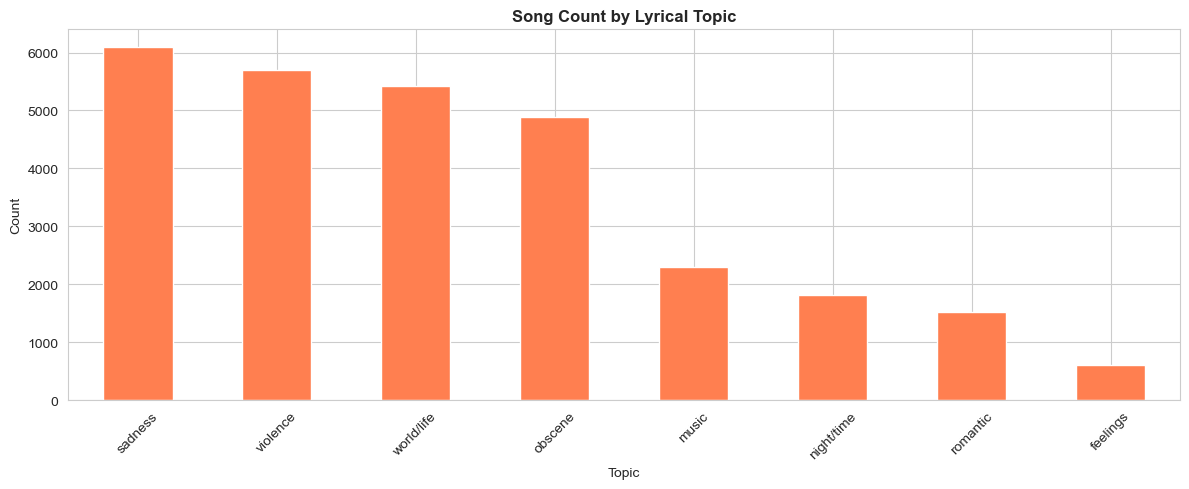

In [13]:
# Lyrical topic count — how many songs per topic label
topic_counts = df['topic'].value_counts()
topic_counts.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Song Count by Lyrical Topic', fontweight='bold')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** `world/life` is the most common topic label, followed by `romantic` and `obscene`. This reflects both the dataset's composition and the dominance of pop music (which leans romantic and world/life). These topic labels will be used post-clustering to validate whether songs with the same topic end up in the same cluster.

---
## Step 2: Bivariate Analysis

Bivariate analysis compares two columns at a time to identify relationships and correlations. Our primary tool here is the correlation heatmap. If two features have a correlation above 0.7, they are measuring nearly the same thing and one can be dropped without losing information. We then use scatter plots to visually confirm the relationships between our strongest features.

### 2a. Correlation Heatmap

This heatmap shows a pairwise correlation between all 15 score columns. Each cell represents how strongly two features move together across all 28,362 songs. Values near 1 (shown in dark red) indicate strong positive correlation. Values near 0 (shown in white) indicate no relationship. The key threshold used for dropping a column is 0.7 or above.

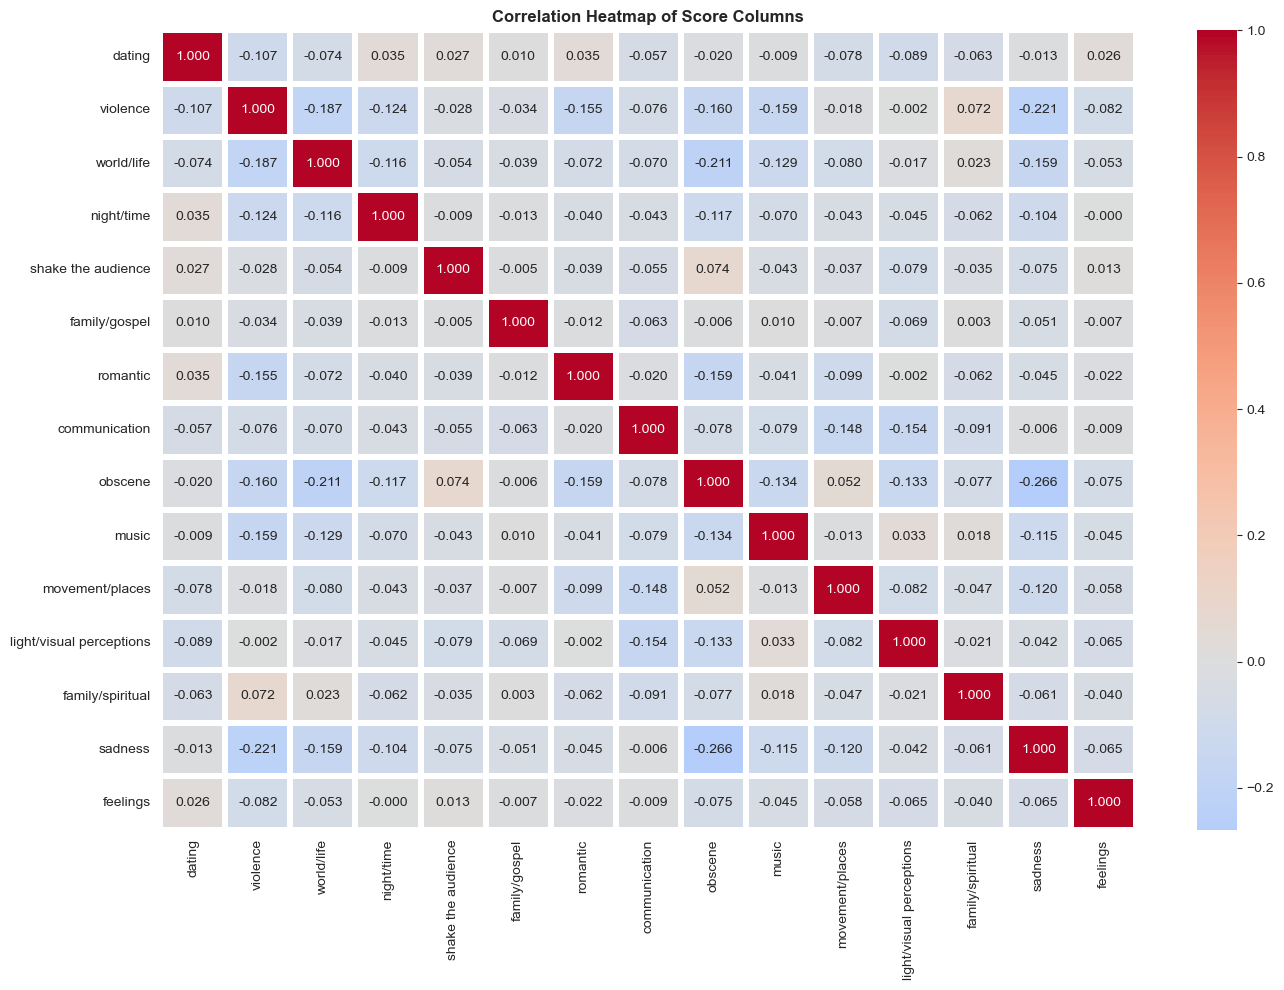

In [26]:
corr = df[score_cols].corr()
heatmap_data = corr
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    center=0,
    linewidths=3
)
plt.title('Correlation Heatmap of Score Columns', fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** The heatmap shows no strongly correlated pairs. Most cells are light-colored, indicating weak relationships across all feature pairs. This means that each feature is independent. 

### 2b. Top Correlated Pairs 

Since the heatmap is hard to look at because of how low the correlations across the board are. This code extracts and ranks every feature pair by correlation strength. We use the upper triangle of the correlation matrix to avoid counting each pair twice. Any pair above 0.7 is a strong candidate for dropping one column.

In [28]:

upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = upper_triangle.stack().sort_values(ascending=False)
top_pairs = (
    upper_triangle
    .unstack()
    .dropna()
    .abs()
    .sort_values(ascending=False)
)
print('Top 15 most correlated feature pairs:')
print(top_pairs.head(15).round(4))
print()
print('High correlation pairs: None')
high = top_pairs[top_pairs > 0.7]
print(high if len(high) > 0 else 'None found above 0.7')

Top 15 most correlated feature pairs:
sadness                   obscene          0.2661
                          violence         0.2211
obscene                   world/life       0.2115
world/life                violence         0.1869
obscene                   violence         0.1596
sadness                   world/life       0.1595
music                     violence         0.1591
obscene                   romantic         0.1586
romantic                  violence         0.1553
light/visual perceptions  communication    0.1540
movement/places           communication    0.1479
music                     obscene          0.1339
light/visual perceptions  obscene          0.1332
music                     world/life       0.1286
night/time                violence         0.1241
dtype: float64

High correlation pairs: None
None found above 0.7


**What this shows:** No pairs exceeded a correlation of 0.3. The highest correlation was between `sadness` and `obscene` at 0.27, which is too weak to justify dropping either column on redundancy grounds alone. Combined with the variance analysis, the primary candidates for dropping remain the four low-variance features: `shake the audience`, `family/gospel`, `family/spiritual`, and `dating`.

### 2c. Scatter Plots: Top 4 High-Variance Features

These six scatter plots show every pairwise combination of our four strongest features: `sadness`, `obscene`, `world/life`, and `violence`. Each dot is one song. If dots form a diagonal line, the features are correlated. If they form an L-shape or random cloud, they are independent. The correlation value is shown in each plot title.

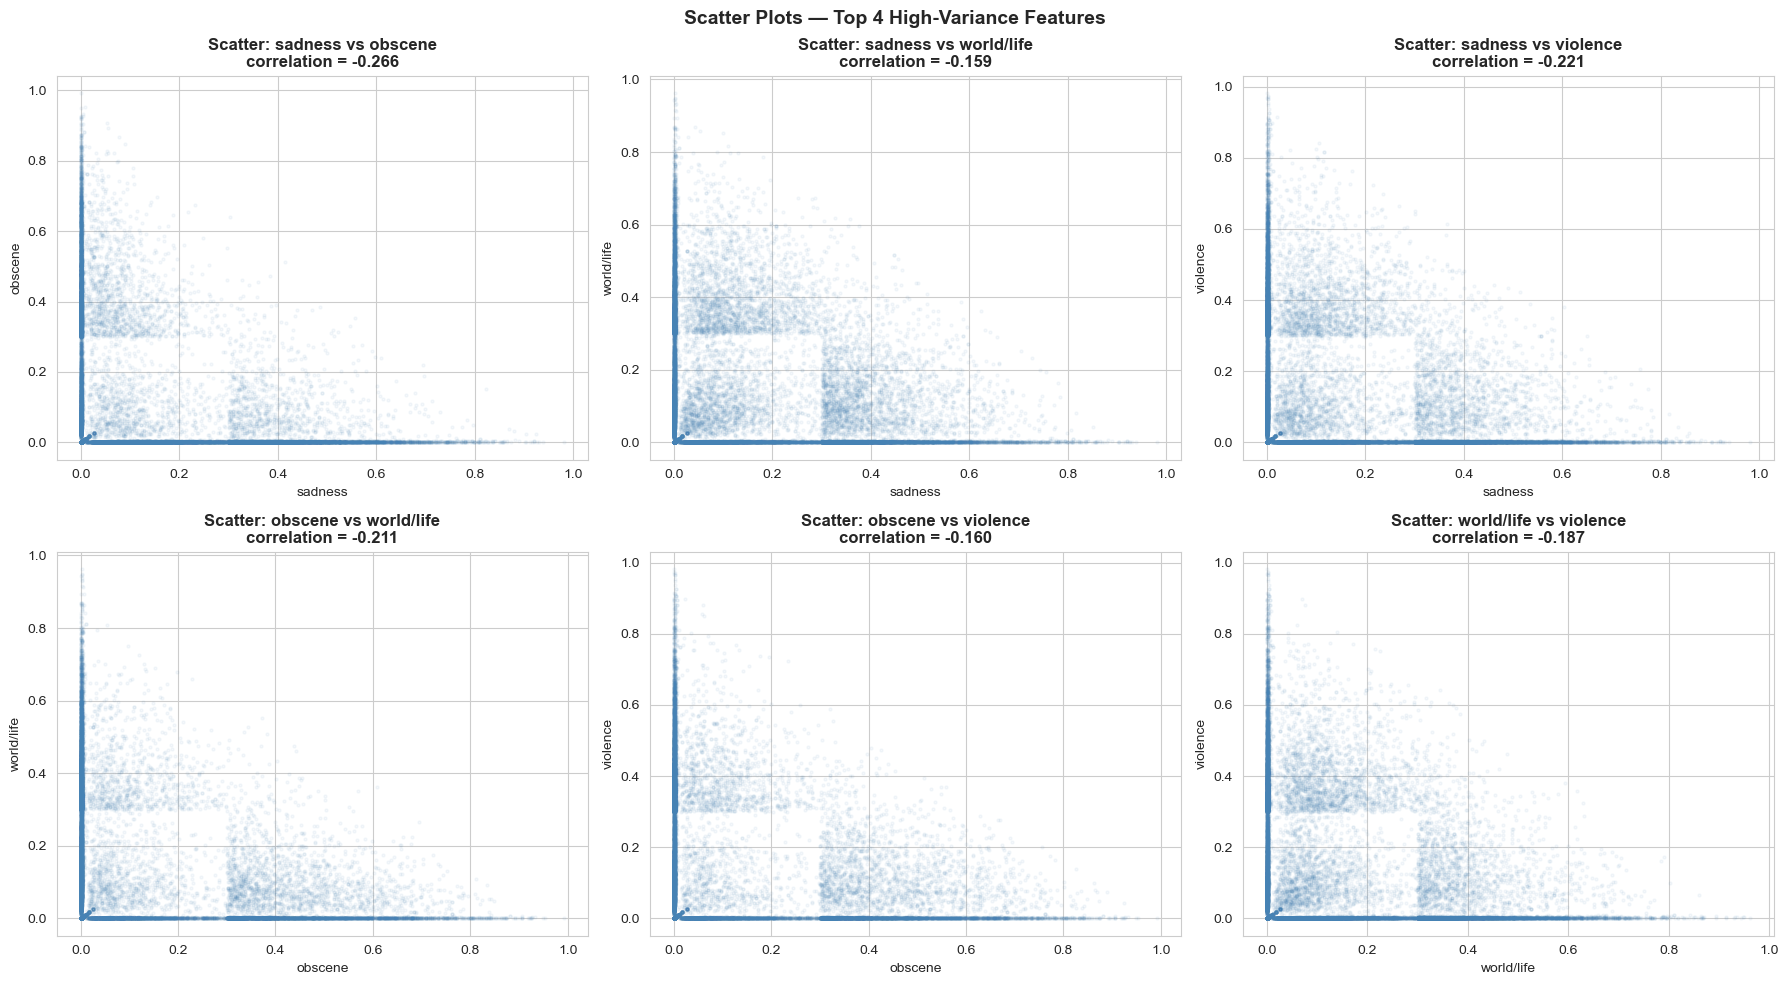

In [29]:
cols_to_plot = ['sadness', 'obscene', 'world/life', 'violence']
pairs = list(itertools.combinations(cols_to_plot, 2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col_x, col_y) in enumerate(pairs):
    corr_val = df[col_x].corr(df[col_y])
    axes[i].scatter(df[col_x], df[col_y], alpha=0.05, s=5, color='steelblue')
    axes[i].set_xlabel(col_x)
    axes[i].set_ylabel(col_y)
    axes[i].set_title(
        f'Scatter: {col_x} vs {col_y}\ncorrelation = {corr_val:.3f}',
        fontweight='bold'
    )

plt.suptitle('Scatter Plots — Top 4 High-Variance Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**What this shows:** All six scatter plots form L-shapes or random clouds rather than diagonal lines, visually confirming the low correlations found in the heatmap. Songs tend to score high on one feature OR another. Almost never both simultaneously. For example, highly obscene songs are rarely sad, and highly violent songs are rarely romantic. The algorithm has genuinely independent dimensions to work with, which should produce more meaningful and distinct clusters!

### 2d. Boxplots: Score Distributions by Genre

These four boxplots show how each of the top 4 features is distributed across genres. Each box represents one genre: the middle line is the median, the box spans the middle 50% of songs, and dots beyond the whiskers are outliers. This tells us whether genres score differently enough on these features that the clustering algorithm will naturally separate them.

/var/folders/g4/zjsymlqx5x96fp0z3y4nn83c0000gn/T/ipykernel_47367/1082693200.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/g4/zjsymlqx5x96fp0z3y4nn83c0000gn/T/ipykernel_47367/1082693200.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/g4/zjsymlqx5x96fp0z3y4nn83c0000gn/T/ipykernel_47367/1082693200.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/g4/zjsymlqx5x96fp0z3y4nn83c0000gn/T/ipykernel_47367/1082693200.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

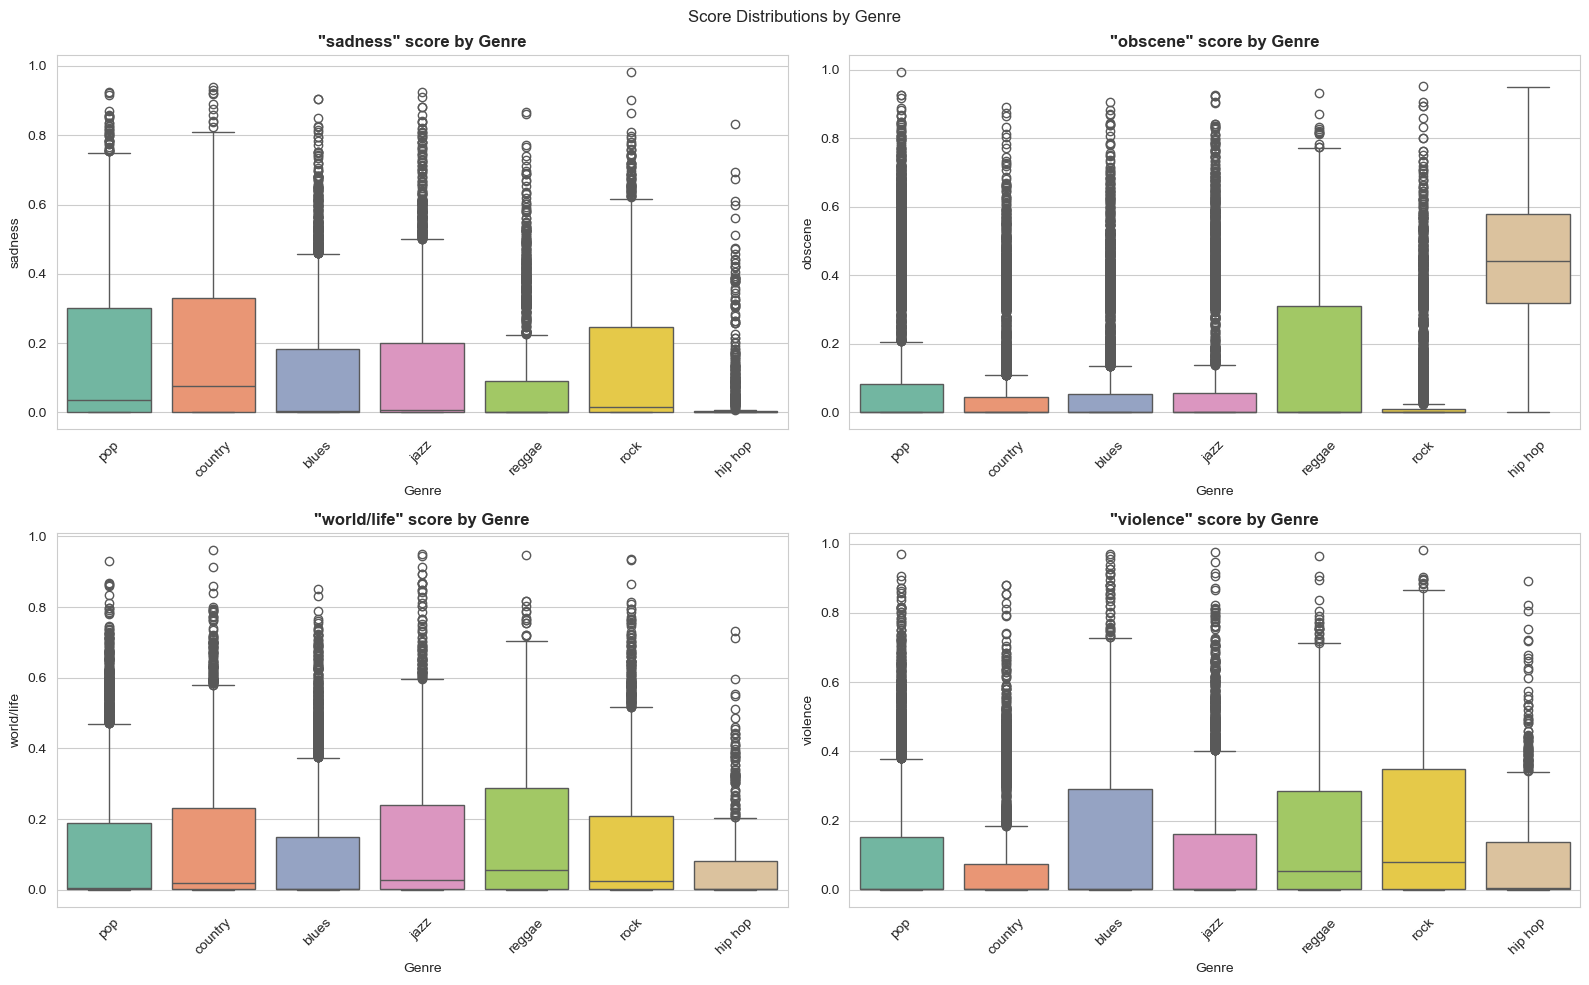

In [30]:
cols_to_plot = ['sadness', 'obscene', 'world/life', 'violence']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(
        data=df,
        x='genre',
        y=col,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f'"{col}" score by Genre', fontweight='bold')
    axes[i].set_xlabel('Genre')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Score Distributions by Genre')
plt.tight_layout()
plt.show()

**Finding:** The boxplots reveal the clearest finding of the EDA: hip hop is a lyrical outlier, scoring dramatically higher on `obscene` than every other genre while scoring near zero on `sadness` and `world/life`. Blues scores surprisingly high on `violence`. Country scores the lowest on `violence` of any genre. Most genres overlap substantially across all four features, meaning **KMeans clusters will most likely cut across multiple genres** rather than simply recreating genre labels.

### 2e. Lyrical Trends Across Decades

This line chart groups songs by decade and plots the average score for each of the top 4 features over time. Since our dataset spans 1950–2019, this reveals whether musical content has shifted across generations. The `age` column (0=newest, 1=oldest) captures this same information, and this chart helps us understand whether retaining `age` as a feature adds meaningful signal to the model.

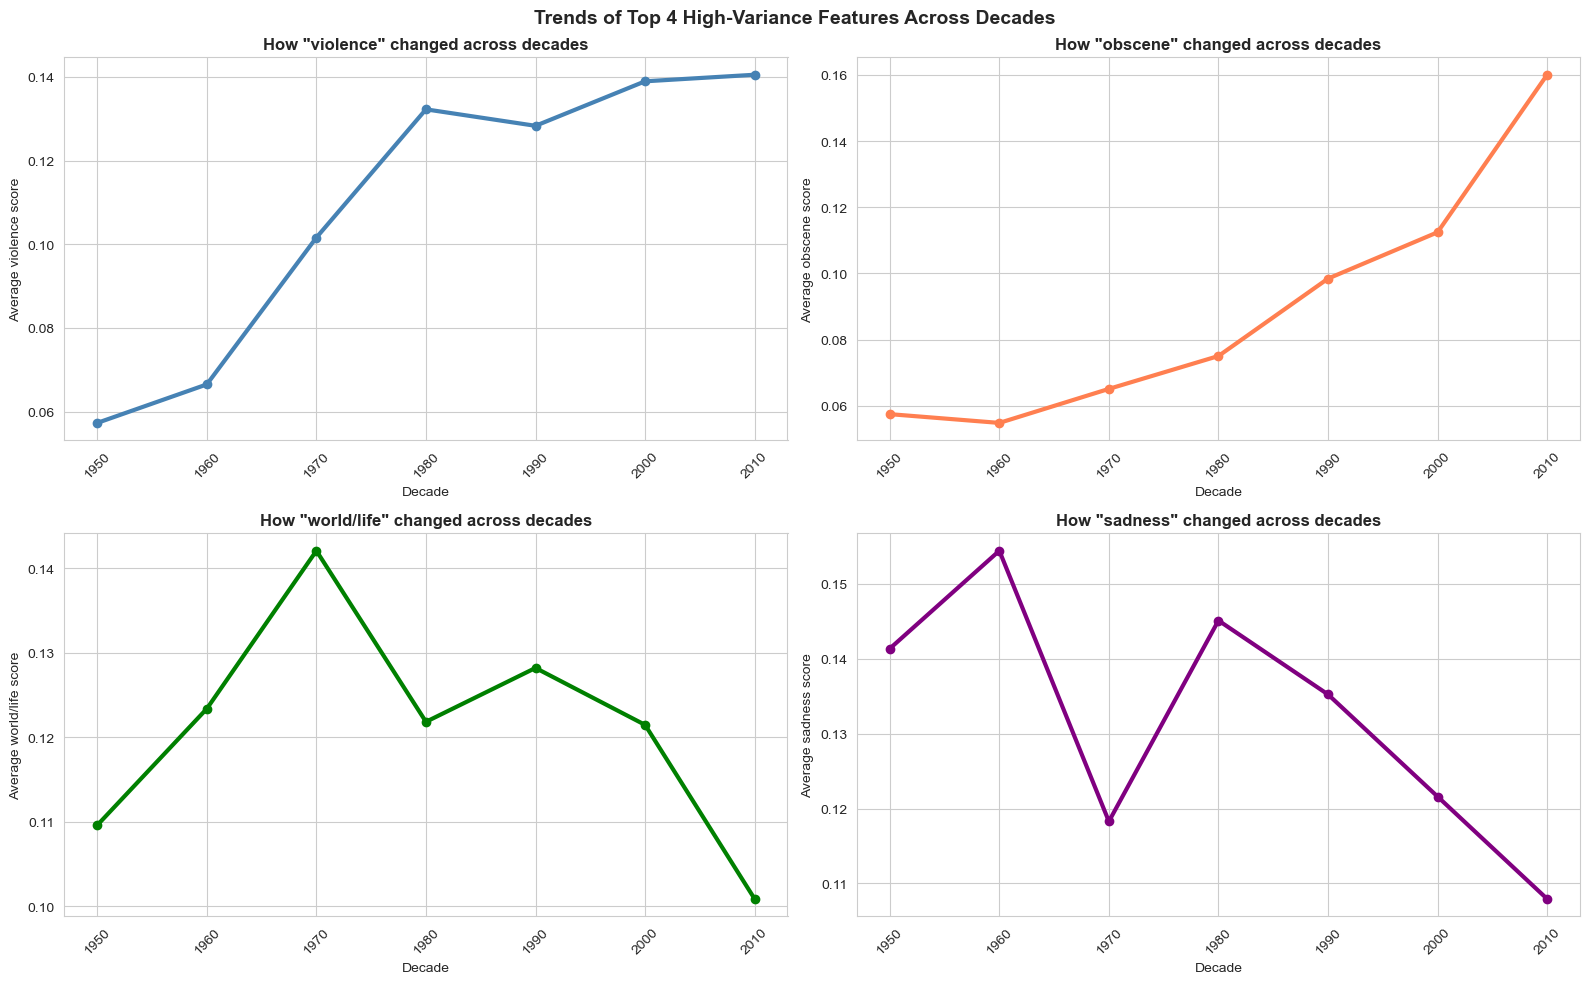

In [31]:
cols_to_plot = ['violence', 'obscene', 'world/life', 'sadness']
colors = ['steelblue', 'coral', 'green', 'purple']

df['decade'] = df['release_date'].apply(lambda x: (x // 10) * 10)
decade_means = df.groupby('decade')[cols_to_plot].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(cols_to_plot, colors)):
    axes[i].plot(
        decade_means['decade'],
        decade_means[col],
        marker='o',
        color=color,
        linewidth=3
    )
    axes[i].set_xlabel('Decade')
    axes[i].set_ylabel(f'Average {col} score')
    axes[i].set_title(f'How "{col}" changed across decades', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xticks(decade_means['decade'])

plt.suptitle('Trends of Top 4 High-Variance Features Across Decades', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Lyrical Theme Trends Across Decades

- **Violence**: steady increase from 1950 to 2010. Modern music is consistently more violent than older music.
- **Obscene**:flat until the 1980s, then rises sharply. Likely driven by the rise of hip hop, which we already identified as the highest obscene genre.
- **World/life**: peaked in the 1970s (protest/folk era) then declined steadily. Modern music is less philosophical than older music.
- **Sadness**: no clear trend, bounces up and down every decade. Sadness appears driven by musical fashion rather than a cultural shift.

**Key takeaway:** Violence and obscene are rising together over time while world/life is falling. This means that the `age` feature may naturally help separate older reflective songs from newer aggressive ones when clustering.

---
## Step 3: Multivariate Analysis

Multivariate analysis examines patterns across multiple columns simultaneously. We use a genre-vs-feature heatmap and a grouped bar chart to see how all genres score across all top features at once. This builds our final hypothesis before moving to the cleaning and modeling steps.

### 3a. Genre vs Feature Heatmap

This heatmap shows the **average score** for each genre on each of the top 4 features. Unlike the correlation heatmap (which measures relationships between features), this heatmap describes what each genre actually looks like in score-space.

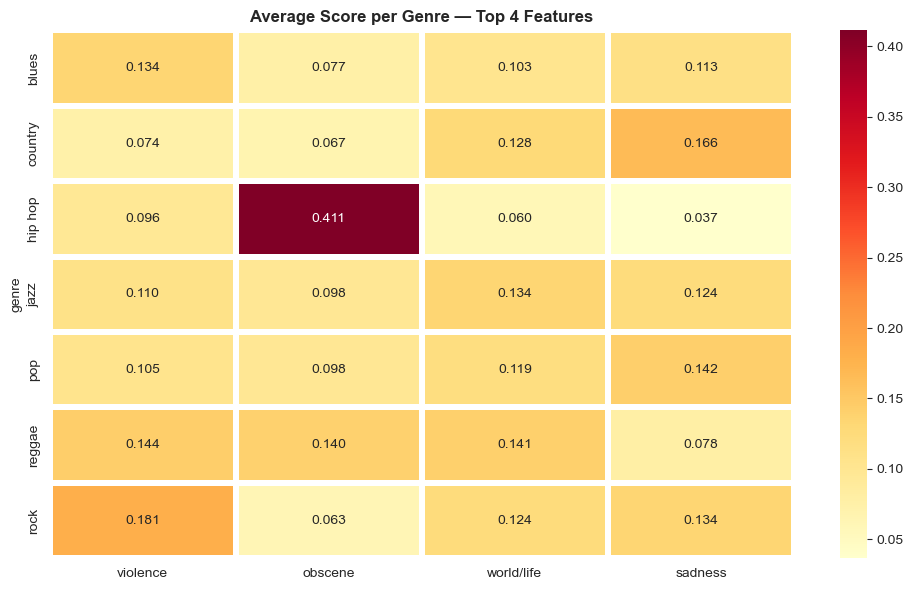

In [32]:

genre_means = df.groupby('genre')[['violence', 'obscene', 'world/life', 'sadness']].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(
    genre_means,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=3
)
plt.title('Average Score per Genre — Top 4 Features', fontweight='bold')
plt.tight_layout()
plt.show()

**What this shows:** Each cell shows the average score for that genre across our top 4 features. Hip hop songs score dramatically higher on obscene (0.411) than any other genre. Blues scores highest on sadness and violence. Country scores lowest on violence of any genre.

**Note:** This heatmap shows average scores per genre (real values 0–>1). This is different from the correlation heatmap which showed relationships between features (-1 to 1). This one describes what each genre looks like; the other described how features relate to each other.

**Why this matters:** This tells us what each genre looks like. When KMeans groups songs into clusters, we can come back to this and check whether those clusters reflect these genre patterns.

### 3b. Grouped Bar Chart: Genre vs Feature

The grouped bar chart provides the same information as the heatmap above but in a format that makes it easier to directly compare genres on a single feature. Each group of bars represents one genre, and each color represents one feature. This makes outliers like hip hop's obscene score immediately visible.

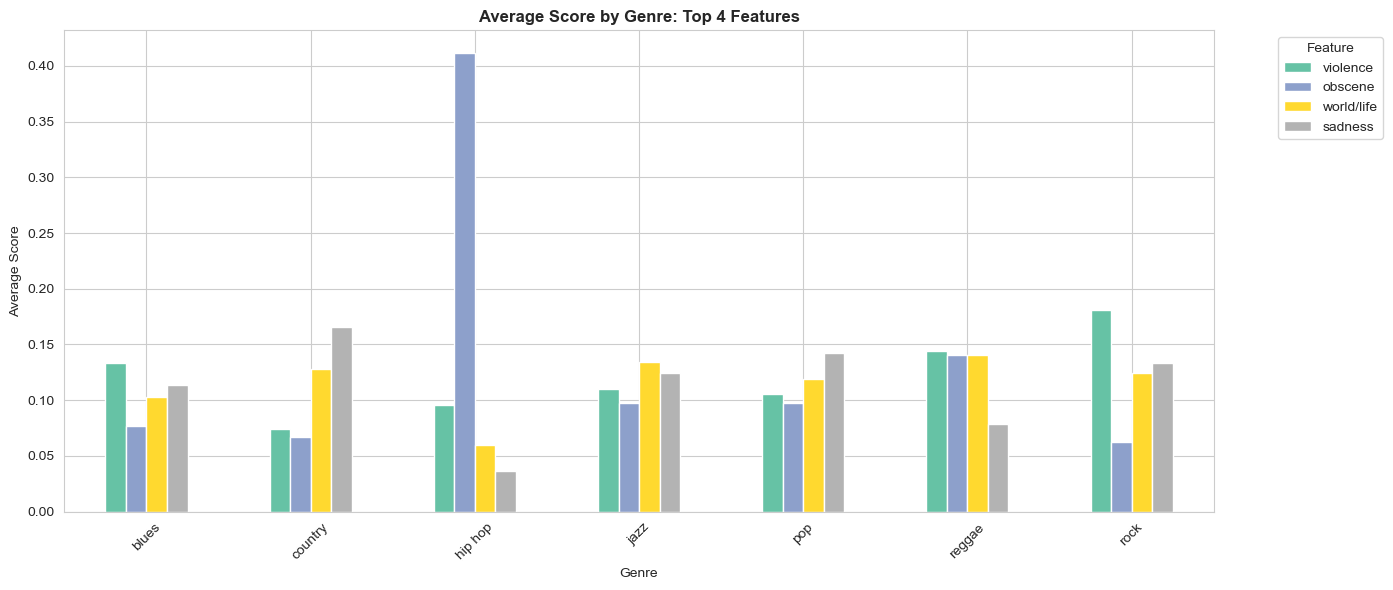

In [33]:
genre_means.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='white')
plt.title('Average Score by Genre: Top 4 Features', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Finding:** Hip hop's obscene bar stands dramatically above all other genres. This confirms that it the clearest genre separator in the dataset. Blues shows the highest sadness and violence bars among all genres. Country's violence bar is nearly flat. These patterns reinforce our expectation that at least one cluster will be dominated by hip hop content.

---
## EDA Summary and Hypothesis ##

### Key Findings ##

**Univariate:** Four features have variance below 0.003 (`shake the audience`, `family/gospel`, `family/spiritual`, `dating`) and are candidates for removal. The four strongest features are `violence`, `obscene`, `sadness`, and `world/life`.

**Bivariate:** No feature pairs exceeded a correlation of 0.3. The highest was `sadness` vs `obscene` at 0.27. No columns need to be dropped for redundancy. All features are measuring genuinely different lyrical content.

**Multivariate:** Hip hop is a lyrical outlier because its is dramatically higher on obscene than all other the genres. Genres overlap substantially across features, suggesting clusters will cut across genre lines rather than recreating genre labels. Violence and obscene have risen steadily since the 1980s while world/life has declined.

### Hypothesis

KMeans will identify between 4–7 meaningful clusters driven primarily by the high  variance features (`violence`, `obscene`, `sadness`, `world/life`). Because all feature correlations are below 0.3, each cluster will represent a unique combination of themes. We expect at least one cluster dominated by hip hop's high obscene signature, and at least one cluster capturing older, more reflective songs with high world/life scores. The `age` feature may contribute natural separation between modern aggressive content and older philosophical content.